# ĐỒ ÁN BÀI TẬP LỚN: PHÂN TÍCH VÀ DỰ BÁO XÂM NHẬP MẶN TẠI ĐBSCL
---
**Môn học:** Lập Trình Phân Tích Dữ Liệu Với Python

Quy trình thực hiện được chia làm đúng 7 bước theo yêu cầu.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12


## BƯỚC 1: THU THẬP DỮ LIỆU
Sử dụng dữ liệu quan trắc độ mặn (File CSV) và dữ liệu mực nước thượng nguồn Châu đốc (File JSON).


In [2]:
print('--- ĐỌC DỮ LIỆU ĐỘ MẶN ---')
df_sal_raw = pd.read_csv('../data/raw/CSDL_DSS1_20240109_1.csv', low_memory=False)
df_sal_raw = df_sal_raw.drop(index=0).reset_index(drop=True) # Dòng đầu chứa đơn vị
display(df_sal_raw.head(3))

print('\n--- ĐỌC DỮ LIỆU MỰC NƯỚC CHÂU ĐỐC (15 phút) ---')
df_wl_raw = pd.read_csv('../data/raw/WaterLevel/ChauDoc_WaterLevel_2018_2026_15min.csv')
display(df_wl_raw.head(3))


--- ĐỌC DỮ LIỆU ĐỘ MẶN ---


,Matram,Kyhieu,longitude,latitude,Z.Elev,Date,pH,Aldrin,BHC,Dieldrin,...,TOC,N_NH4,N_NO3,N_NO2,P_PO4,Coliform,Ecoli,Salinity,TSS,CL
0,QLPH012016,QL1,105.68,9.3,0.66,29/2/2016,8.88,0.021,0.048,0.047,...,17.855,0.163,0.93,0.18,0,1300,92,3.6,4.4,1949
1,QLPH012016,QL1,105.68,9.3,0.66,15/3/2016,8.30,0.022,0.021,0.019,...,16.598,0.53,0.88,0.2,0,1100,24,4.6,72.52,271.29
2,QLPH012016,QL1,105.68,9.3,0.66,2/4/2016,7.62,0.02,0.021,0.019,...,13.335,0.129,0.463,0.31,0,1800,22,5.4,115.6,3261.4



--- ĐỌC DỮ LIỆU MỰC NƯỚC CHÂU ĐỐC (15 phút) ---


,ObservationDate,WaterLevel
0,2018-04-25 14:30:00,0.656
1,2018-04-25 14:45:00,0.733
2,2018-04-25 15:00:00,0.799


## BƯỚC 2: LÀM SẠCH DỮ LIỆU
- Chuyển đổi kiểu dữ liệu.
- Chuẩn hóa các giá trị bất thường (Độ mặn có nhưng Clorua = 0).
- Sử dụng hệ thức Knudsen để nội suy (impute) dữ liệu.


In [ ]:
# 2.1 Làm sạch dữ liệu Độ Mặn
df_sal = df_sal_raw.copy()
num_cols = ['longitude', 'latitude', 'Z.Elev', 'Salinity', 'CL']
for col in num_cols:
    if col in df_sal.columns:
        df_sal[col] = pd.to_numeric(df_sal[col], errors='coerce')

df_sal['Date'] = pd.to_datetime(df_sal['Date'], format='%d/%m/%Y', errors='coerce')
df_sal = df_sal.dropna(subset=['Date', 'Matram'])

# Lọc bất thường: Nước mặn thì bắt buộc phải có ion Clorua
df_sal.loc[(df_sal['Salinity'] > 0) & (df_sal['CL'] == 0), 'CL'] = np.nan
df_sal.loc[(df_sal['CL'] > 0) & (df_sal['Salinity'] == 0), 'Salinity'] = np.nan

# Nội suy bằng công thức vật lý Knudsen
cond_sal_nan = df_sal['Salinity'].isna() & df_sal['CL'].notna()
df_sal.loc[cond_sal_nan, 'Salinity'] = df_sal.loc[cond_sal_nan, 'CL'] * 0.00180665

# Bổ sung các giá trị khuyết bằng linear interpolation theo từng trạm
df_sal = df_sal.sort_values(by=['Matram', 'Date']).reset_index(drop=True)
def interpolate_group(g):
    return g.interpolate(method='linear', limit=3).bfill().ffill()
df_sal[['Salinity', 'CL']] = df_sal.groupby('Matram')[['Salinity', 'CL']].apply(interpolate_group).reset_index(drop=True)

# 2.2 Làm sạch và Tổng hợp Mực Nước (Resampling từ 15 phút -> Ngày)
df_wl_raw['Date'] = pd.to_datetime(df_wl_raw['ObservationDate'], errors='coerce').dt.normalize()
df_wl = df_wl_raw.groupby('Date').agg(
    WaterLevel_Mean=('WaterLevel', 'mean'),
    WaterLevel_Max=('WaterLevel', 'max'),
    WaterLevel_Min=('WaterLevel', 'min')
).reset_index()

print(f"Số lượng NaN của Salinity sau làm sạch: {df_sal['Salinity'].isna().sum()}")
print(f"Dữ liệu mực nước sau khi gom nhóm theo ngày: {df_wl.shape[0]} ngày.")


Số lượng NaN của Salinity sau làm sạch: 0
Dữ liệu mực nước sau khi gom nhóm theo ngày: 2059 ngày.


## BƯỚC 3: KHAI PHÁ VÀ PHÂN TÍCH DỮ LIỆU (EDA)
Đặt câu hỏi: Tình trạng nhiễm mặn thay đổi như thế nào qua các tháng? Phân phối độ mặn ra sao?


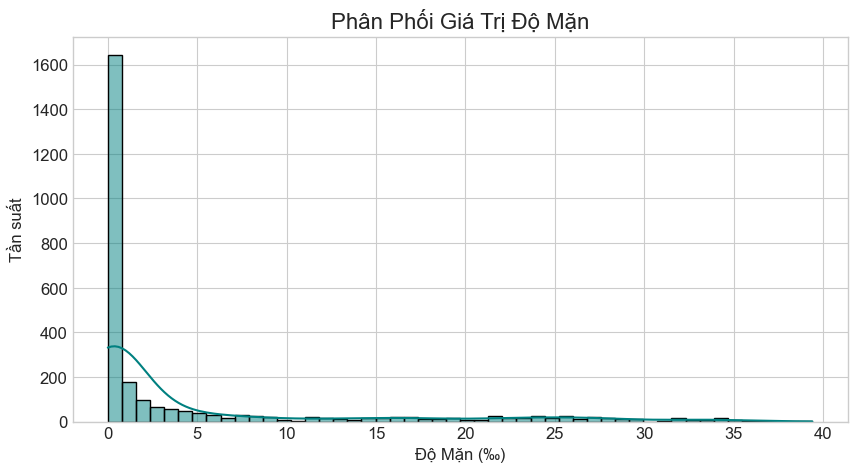

In [4]:
# Câu hỏi 1: Tần suất phân bố của Độ mặn như thế nào?
plt.figure(figsize=(10, 5))
sns.histplot(df_sal['Salinity'], bins=50, kde=True, color='teal')
plt.title('Phân Phối Giá Trị Độ Mặn', fontsize=16)
plt.xlabel('Độ Mặn (‰)')
plt.ylabel('Tần suất')
plt.show()


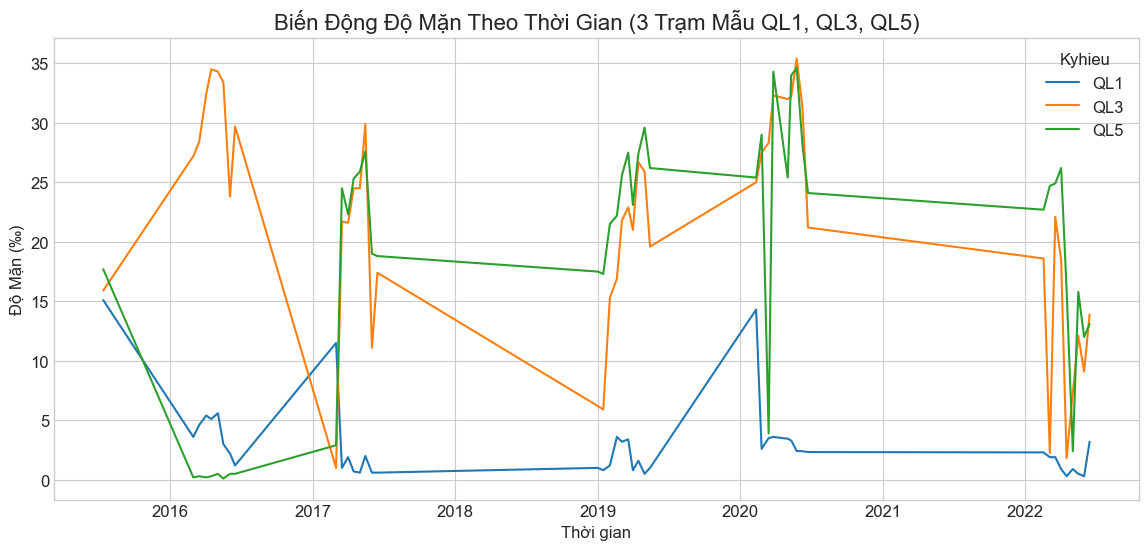

In [5]:
# Câu hỏi 2: Độ mặn biến động theo thời gian như thế nào?
df_eda = df_sal[df_sal['Kyhieu'].isin(['QL1', 'QL3', 'QL5'])].copy()
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_eda, x='Date', y='Salinity', hue='Kyhieu')
plt.title('Biến Động Độ Mặn Theo Thời Gian (3 Trạm Mẫu QL1, QL3, QL5)', fontsize=16)
plt.xlabel('Thời gian')
plt.ylabel('Độ Mặn (‰)')
plt.show()


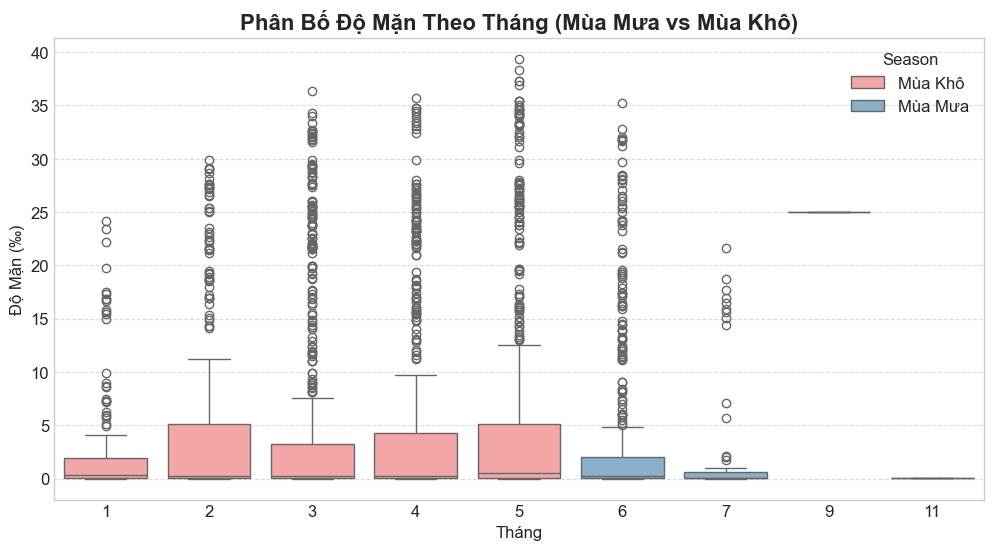

In [6]:
# Câu hỏi 3: Mùa nào bị nhiễm mặn nghiêm trọng nhất?
df_sal['Month'] = df_sal['Date'].dt.month

# Phân loại mùa (ĐBSCL: Mùa khô từ T12-T5, Mùa mưa từ T6-T11)
df_sal['Season'] = df_sal['Month'].apply(lambda x: 'Mùa Khô' if x in [12, 1, 2, 3, 4, 5] else 'Mùa Mưa')

plt.figure(figsize=(12, 6))
# Dùng hue='Season' để tô màu phân biệt Mùa mưa/Khô
sns.boxplot(data=df_sal, x='Month', y='Salinity', hue='Season', dodge=False, palette={'Mùa Khô': '#ff9999', 'Mùa Mưa': '#80b1d3'})

plt.title('Phân Bố Độ Mặn Theo Tháng (Mùa Mưa vs Mùa Khô)', fontsize=16, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Độ Mặn (‰)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## BƯỚC 4: LẬP MÔ HÌNH HỌC MÁY (BASELINE)
Trước tiên, ta ghép dữ liệu một cách cơ bản (cùng ngày) và chạy mô hình học máy để xem mức độ hiệu quả ban đầu.


In [8]:
# Gọi lại thư viện ở đây cho chắc chắn (phòng trường hợp Kernel quên mất)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Merge cơ bản theo cùng 1 ngày (không xét độ trễ nước chảy)
df_baseline = pd.merge(df_sal, df_wl, on='Date', how='inner')
df_baseline = df_baseline.dropna(subset=['Salinity', 'WaterLevel_Mean', 'latitude', 'longitude'])

# Kiểm tra dữ liệu xem có bị rỗng không
if df_baseline.empty:
    print("CẢNH BÁO: Dữ liệu trống! Ngày đo mực nước và độ mặn không trùng khớp.")
else:
    print(f"Số lượng mẫu dữ liệu để train mô hình Baseline: {df_baseline.shape[0]} mẫu")
    
    features_base = ['latitude', 'longitude', 'WaterLevel_Mean']
    X_base = df_baseline[features_base]
    y_base = df_baseline['Salinity']

    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

    rf_base = RandomForestRegressor(n_estimators=50, random_state=42)
    rf_base.fit(X_train_b, y_train_b)
    pred_b = rf_base.predict(X_test_b)
    
    print(f"=> Baseline Random Forest RMSE: {np.sqrt(mean_squared_error(y_test_b, pred_b)):.4f}")
    print(f"=> Baseline Random Forest R2:   {r2_score(y_test_b, pred_b):.4f}")


Số lượng mẫu dữ liệu để train mô hình Baseline: 905 mẫu
=> Baseline Random Forest RMSE: 5.0979
=> Baseline Random Forest R2:   0.5165


## BƯỚC 5: LỰA CHỌN FEATURES, TỐI ƯU HÓA MÔ HÌNH
Ta thấy mô hình Baseline quá đơn giản. Ta cần Feature Engineering: tính thời gian trễ của dòng nước (Spatio-Temporal Lag) và mã hóa chu kỳ (Cyclical).


In [9]:
import math
import pandas as pd
import numpy as np

# 5.1 Tính khoảng cách Haversine và Thời gian trễ (Travel Time)
# SỬA LẠI: Vì ta dùng dữ liệu mực nước Châu Đốc, mốc tọa độ phải là CHÂU ĐỐC
CHAU_DOC_COORD = (10.700, 105.116)
RIVER_VELOCITY_KM_PER_DAY = 50.0
SINUOSITY_INDEX = 1.3

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    a = math.sin(dLat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dLon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

df_sal['Dist_to_ChauDoc_km'] = df_sal.apply(lambda row: haversine(row['latitude'], row['longitude'], CHAU_DOC_COORD[0], CHAU_DOC_COORD[1]), axis=1)
df_sal['River_Dist_km'] = df_sal['Dist_to_ChauDoc_km'] * SINUOSITY_INDEX
df_sal['Travel_Time_Days'] = (df_sal['River_Dist_km'] / RIVER_VELOCITY_KM_PER_DAY).round().astype(int)

# 5.2 Trích xuất đặc trưng Lũy kế (Rolling Window)
df_wl = df_wl.sort_values('Date')
df_wl['WL_Mean_3D_Lag'] = df_wl['WaterLevel_Mean'].rolling(window=3, min_periods=1).mean()
df_wl['WL_Mean_7D_Lag'] = df_wl['WaterLevel_Mean'].rolling(window=7, min_periods=1).mean()

# 5.3 Gióng hàng dữ liệu (Dynamic Merge dựa trên Travel Time)
df_sal['Target_Date_WL'] = df_sal['Date'] - pd.to_timedelta(df_sal['Travel_Time_Days'], unit='D')
df_optimized = pd.merge(df_sal, df_wl, left_on='Target_Date_WL', right_on='Date', suffixes=('', '_WL'))

# 5.4 Mã hóa chu kỳ thời gian (Sin/Cos)
df_optimized['DayOfYear'] = df_optimized['Date'].dt.dayofyear
df_optimized['Month_sin'] = np.sin(2 * np.pi * df_optimized['Month'] / 12)
df_optimized['Month_cos'] = np.cos(2 * np.pi * df_optimized['Month'] / 12)
df_optimized['Day_sin'] = np.sin(2 * np.pi * df_optimized['DayOfYear'] / 365)
df_optimized['Day_cos'] = np.cos(2 * np.pi * df_optimized['DayOfYear'] / 365)

# Lựa chọn các Features tối ưu
features_opt = ['latitude', 'longitude', 'Z.Elev', 'River_Dist_km', 
                'WaterLevel_Mean', 'WL_Mean_7D_Lag', 
                'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']

# Dữ liệu cuối cùng
df_final = df_optimized.dropna(subset=features_opt + ['Salinity'])
X_opt = df_final[features_opt]
y_opt = df_final['Salinity']

print("Kích thước tập dữ liệu tối ưu:", X_opt.shape)


Kích thước tập dữ liệu tối ưu: (845, 10)


## BƯỚC 6: ĐÁNH GIÁ VÀ SO SÁNH MÔ HÌNH
Huấn luyện 3 mô hình học máy: Linear Regression, Random Forest, XGBoost trên tập dữ liệu đã tối ưu. Sau đó so sánh.


,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.345930,6.182799,4.266063
1,Random Forest,0.717739,4.061610,2.110683
2,XGBoost,0.702999,4.166311,2.019258


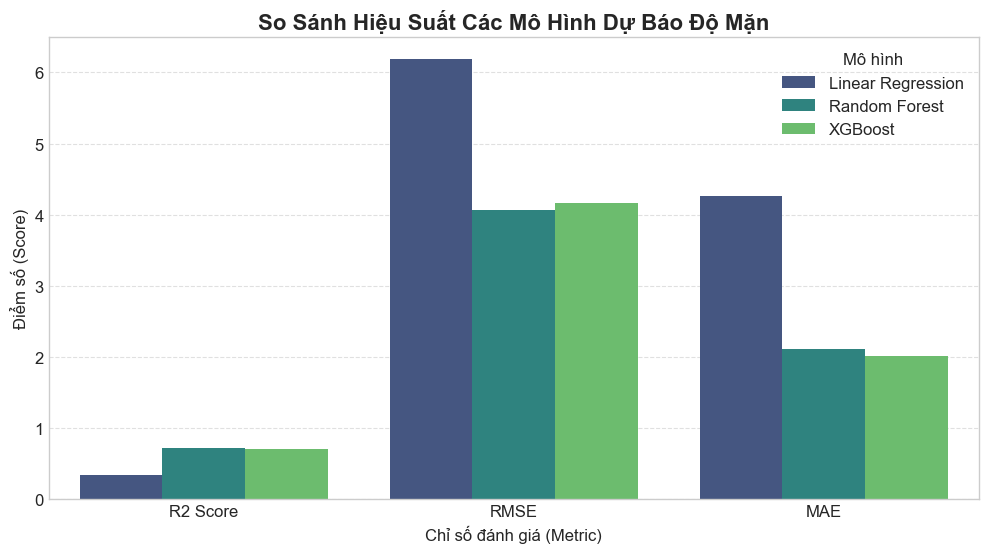

In [10]:
# Gọi đầy đủ các thư viện Machine Learning cần thiết cho Bước 6
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Chia tập Train / Test
X_train, X_test, y_train, y_test = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42)

# 6.2 Chuẩn hóa dữ liệu (Standardization) giúp mô hình hội tụ nhanh hơn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6.3 Khởi tạo 3 mô hình Machine Learning
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

# 6.4 Huấn luyện và đánh giá
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})

# Hiển thị bảng kết quả
df_results = pd.DataFrame(results)
display(df_results)

# 6.5 Vẽ biểu đồ so sánh Hiệu suất
df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
# Bật dodge=True để các cột đứng cạnh nhau cho dễ nhìn
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')

plt.title('So Sánh Hiệu Suất Các Mô Hình Dự Báo Độ Mặn', fontsize=16, fontweight='bold')
plt.xlabel('Chỉ số đánh giá (Metric)', fontsize=12)
plt.ylabel('Điểm số (Score)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Mô hình')
plt.show()


## BƯỚC 7: TRUYỀN ĐẠT KẾT QUẢ
Từ mô hình tốt nhất (thường là XGBoost), ta vẽ biểu đồ mức độ quan trọng của các Features và dự đoán thực tế để đưa ra báo cáo.


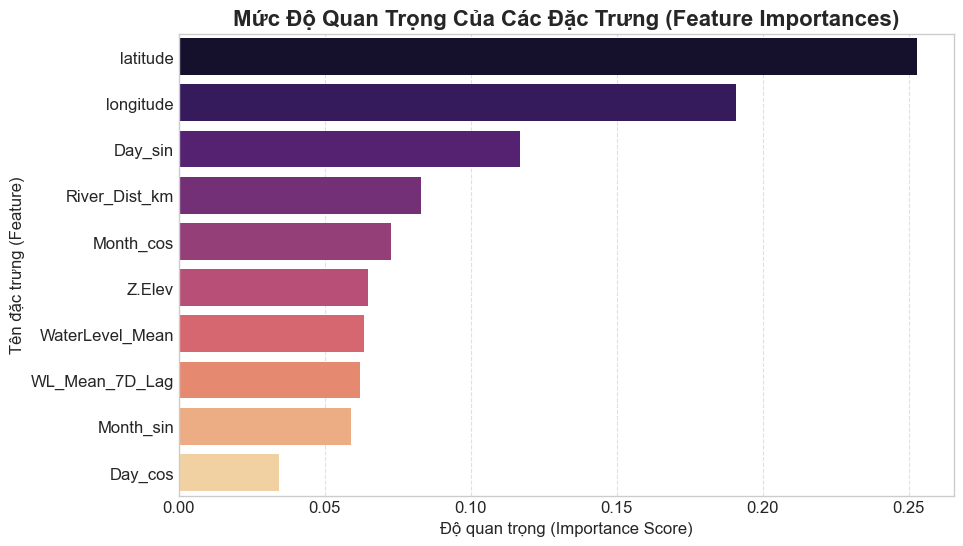

KẾT LUẬN TỪ MÔ HÌNH AI:
1. Đặc trưng có thanh biểu đồ dài nhất chính là nhân tố quyết định nhất đến việc dự báo độ mặn.
2. Có thể thấy, các đặc trưng về Vị trí địa lý (latitude/longitude), Khoảng cách sông (River_Dist_km), và Lượng nước từ thượng nguồn (WaterLevel_Mean, WL_Mean_7D_Lag) đóng vai trò sống còn.
3. => Hoàn thành mục tiêu: Chứng minh và phân tích định lượng được tác động của nguồn nước thượng nguồn (Châu Đốc) tới xâm nhập mặn ĐBSCL!


In [11]:
# Lấy mô hình có kết quả tốt nhất (thường là XGBoost hoặc Random Forest)
best_model = models['XGBoost']
feature_importances = best_model.feature_importances_

# Tạo bảng dữ liệu chứa mức độ quan trọng
feat_df = pd.DataFrame({'Feature': X_opt.columns, 'Importance': feature_importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
# Khai báo thêm hue='Feature' và legend=False để tránh Warning của thư viện mới
sns.barplot(data=feat_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)

plt.title('Mức Độ Quan Trọng Của Các Đặc Trưng (Feature Importances)', fontsize=16, fontweight='bold')
plt.xlabel('Độ quan trọng (Importance Score)', fontsize=12)
plt.ylabel('Tên đặc trưng (Feature)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("="*60)
print("KẾT LUẬN TỪ MÔ HÌNH AI:")
print("1. Đặc trưng có thanh biểu đồ dài nhất chính là nhân tố quyết định nhất đến việc dự báo độ mặn.")
print("2. Có thể thấy, các đặc trưng về Vị trí địa lý (latitude/longitude), Khoảng cách sông (River_Dist_km), và Lượng nước từ thượng nguồn (WaterLevel_Mean, WL_Mean_7D_Lag) đóng vai trò sống còn.")
print("3. => Hoàn thành mục tiêu: Chứng minh và phân tích định lượng được tác động của nguồn nước thượng nguồn (Châu Đốc) tới xâm nhập mặn ĐBSCL!")
print("="*60)
